In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import drive
from tqdm import tqdm
import dlib
#!pip install mediapipe
#import mediapipe as mp
import seaborn as sns
from scipy.fftpack import fft2, fftshift
from scipy import ndimage
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
from PIL import Image
from time import time
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA
from skimage.feature import hog
from imutils import face_utils
import argparse
import imutils
import cv2
!wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
!bunzip2 shape_predictor_68_face_landmarks.dat.bz2

!pip install insightface onnxruntime
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier


from insightface.app import FaceAnalysis
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')

--2025-12-12 22:53:36--  http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Resolving dlib.net (dlib.net)... 107.180.26.78
Connecting to dlib.net (dlib.net)|107.180.26.78|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2 [following]
--2025-12-12 22:53:36--  https://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
Connecting to dlib.net (dlib.net)|107.180.26.78|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64040097 (61M)
Saving to: ‘shape_predictor_68_face_landmarks.dat.bz2’

shape_predictor_68_ 100%[===================>]  61.07M  19.3MB/s    in 3.2s    

2025-12-12 22:53:40 (19.3 MB/s) - ‘shape_predictor_68_face_landmarks.dat.bz2’ saved [64040097/64040097]

bunzip2: Output file shape_predictor_68_face_landmarks.dat already exists.
Mounted at /content/drive


In [3]:
path = "drive/MyDrive/datasci281/data/fer_2013/"
train_dir = path + "train/"
test_dir = path + "test/"
emotion_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']
df_train = pd.DataFrame(columns=['path', 'expression'])
df_test = pd.DataFrame(columns=['path', 'expression'])

for expression in os.listdir(train_dir):
    dir_ = train_dir + expression
    #print(dir_)
    for img_name in os.listdir(dir_):
        img_path = dir_ + '/' + img_name
        df_train = pd.concat([df_train, pd.DataFrame({'path': [img_path], 'expression': [expression]})], ignore_index=True)
# df_train.head()
for expression in os.listdir(test_dir):
    dir_ = test_dir + expression
    for img_name in os.listdir(dir_):
        img_path = dir_ + '/' + img_name
        df_test = pd.concat([df_test, pd.DataFrame({'path': [img_path], 'expression': [expression]})], ignore_index=True)



In [4]:
df_train.head()

,path,expression
0,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear
1,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear
2,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear
3,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear
4,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear


In [5]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

Train shape: (28709, 2)
Test shape: (7178, 2)


In [6]:
df_train['expression'].value_counts()

,count
expression,
happy,7215
neutral,4965
sad,4830
fear,4097
angry,3995
surprise,3171
disgust,436


In [7]:
df_test['expression'].value_counts()

,count
expression,
happy,1774
sad,1247
neutral,1233
fear,1024
angry,958
surprise,831
disgust,111


In [8]:
#Ecode the labels
le = LabelEncoder()
df_train['label'] = le.fit_transform(df_train['expression'])
df_test['label']  = le.transform(df_test['expression'])

In [9]:
df_train.head()

,path,expression,label
0,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear,2
1,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear,2
2,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear,2
3,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear,2
4,drive/MyDrive/datasci281/data/fer_2013/train/f...,fear,2


In [10]:

detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
app = FaceAnalysis(name="buffalo_l")
app.prepare(ctx_id=0, det_size=(224, 224))


def normalize_landmarks(pts):
    pts_centered = pts - pts[30]  # nose tip
    eye_dist = np.linalg.norm(pts[36] - pts[45]) + 1e-6
    pts_norm = pts_centered / eye_dist
    return pts_norm.flatten()  # (136,)


def extract_landmarks_from_path(img_path, detector, predictor):
    img = cv2.imread(img_path)
    if img is None:
        raise RuntimeError(f"Could not load {img_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (96, 96))   # upscale from FER2013 (48×48)

    rects = detector(gray, 1)

    if len(rects) == 0:
        # fallback: whole image
        h, w = gray.shape
        rects = [dlib.rectangle(0, 0, w, h)]

    shape = predictor(gray, rects[0])

    pts = np.array(
        [[shape.part(i).x, shape.part(i).y] for i in range(68)],
        dtype=np.float32
    )

    return pts



def build_landmark_dataset(df, detector, predictor):
    X = []
    y = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc="Landmarks"):
        try:
            pts = extract_landmarks_from_path(row["path"], detector, predictor)
            feat = normalize_landmarks(pts)
        except:
            feat = np.zeros(136, dtype=np.float32)

        X.append(feat)
        y.append(row["expression"])

    return np.array(X, dtype=np.float32), np.array(y)


def load_fer2013_hog(data_dir, ppc=8, cpb=2, ori=9):
    X = []
    y = []
    image_paths = []

    for label, emotion in enumerate(emotion_names):
        emotion_path = os.path.join(data_dir, emotion)
        if not os.path.isdir(emotion_path):
            continue

        for f in tqdm(os.listdir(emotion_path), desc=emotion):
            path = os.path.join(emotion_path, f)
            img = Image.open(path).convert('L').resize((48, 48))
            arr = np.array(img)

            feat = hog(
                arr,
                orientations=ori,
                pixels_per_cell=(ppc, ppc),
                cells_per_block=(cpb, cpb),
                block_norm="L2-Hys",
                feature_vector=True
            )

            X.append(feat)
            y.append(label)
            image_paths.append(path)

    return np.array(X, dtype=np.float32), np.array(y), image_paths



def extract_insightface_embedding(path):
    img = cv2.imread(path)
    if img is None:
        return np.zeros(512, dtype=np.float32)

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    faces = app.get(img)

    if len(faces) == 0:
        return np.zeros(512, dtype=np.float32)

    return np.array(faces[0].embedding, dtype=np.float32)


def subsample(X, y, n=5000):
    if len(X) <= n:
        return X, y
    idx = np.random.choice(len(X), size=n, replace=False)
    return X[idx], y[idx]

download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:02<00:00, 97295.24KB/s] 


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (224, 224)


In [11]:
#X_hog, y, image_paths = load_fer2013_hog(train_dir) # add rrename vars



In [12]:
# --- LANDMARKS ---
#X_land, _ = build_landmark_dataset(df_train, detector, predictor)



In [13]:
# --- INSIGHTFACE ---
#X_emb = np.vstack([extract_insightface_embedding(p) for p in tqdm(image_paths)])



In [14]:
# --- FINAL CONCATENATION ---
#X_final = np.hstack([X_hog, X_land, X_emb])

#print("Final Feature Shape:", X_final.shape)

In [15]:
#print("HOG", X_hog.shape)
#print("Landmarks", X_land.shape)
#print("Insightface", X_emb.shape )

In [16]:
#np.save("drive/MyDrive/datasci281/X_train_embeddings.npy", X_final)
#np.save("drive/MyDrive/datasci281/y_train_embeddings.npy", y)
#np.save("drive/MyDrive/datasci281/X_train_hog.npy", X_hog)
#np.save("drive/MyDrive/datasci281/X_train_land.npy", X_land)
#np.save("drive/MyDrive/datasci281/X_train_arcface.npy", X_emb)

# X_train, X_Val, y_train, y_Val = train_test_split(
#     X_train_embeddings,
#     y,
#     test_size=0.30,      # 30% goes to val
#     random_state=42,
#     stratify=y
# )

<h1>loading the embeddings back into variables</h1>

In [17]:
import numpy as np

X_final = np.load("drive/MyDrive/datasci281/X_train_embeddings.npy")
y       = np.load("drive/MyDrive/datasci281/y_train_embeddings.npy")
X_hog   = np.load("drive/MyDrive/datasci281/X_train_hog.npy")
X_land  = np.load("drive/MyDrive/datasci281/X_train_land.npy")
X_emb   = np.load("drive/MyDrive/datasci281/X_train_arcface.npy")

# X_final = np.load("drive/MyDrive/datasci281/X_test_embeddings.npy")
# y       = np.load("drive/MyDrive/datasci281/y_test_embeddings.npy")
# X_hog   = np.load("drive/MyDrive/datasci281/X_test_hog.npy")
# X_land  = np.load("drive/MyDrive/datasci281/X_test_land.npy")
# X_emb   = np.load("drive/MyDrive/datasci281/X_test_arcface.npy")


# PCA

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (28709, 1548)


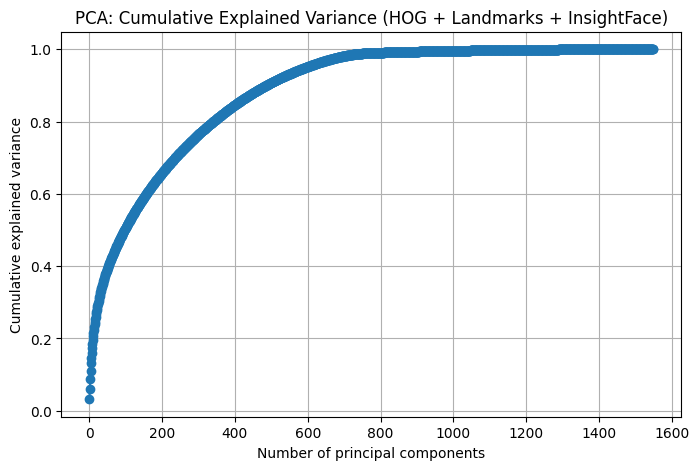

90% variance → 486 components
95% variance → 596 components
99% variance → 785 components


In [19]:
# Fit PCA on all components to inspect variance
pca_full = PCA(svd_solver="randomized", random_state=42)
pca_full.fit(X_scaled)

expl_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.title("PCA: Cumulative Explained Variance (HOG + Landmarks + InsightFace)")
plt.show()

# Optional: print how many components to reach 90%, 95%
for target in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cum_var, target) + 1
    print(f"{target*100:.0f}% variance → {k} components")

## Reducing to get 95% of variance

In [20]:
pca = PCA(n_components=596, svd_solver="randomized", random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_final.shape)
print("Reduced shape:", X_pca.shape)  # e.g. (28709, ~200)


Original shape: (28709, 1548)
Reduced shape: (28709, 596)


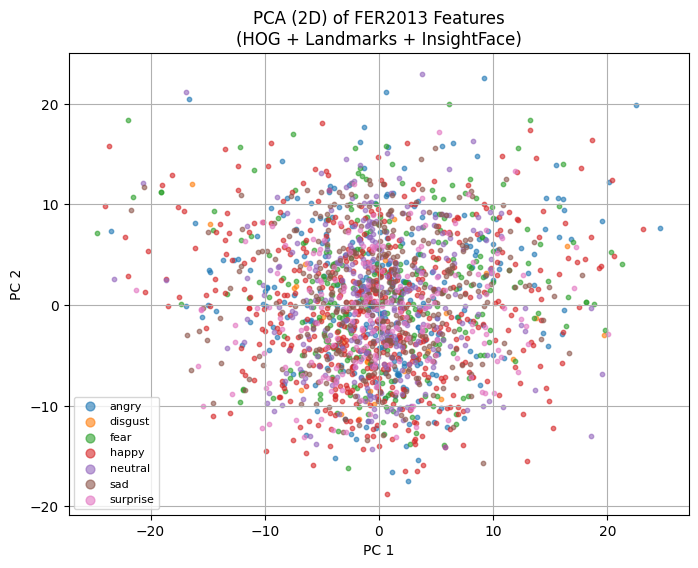

In [21]:

# 2D PCA for visualization
pca_vis = PCA(n_components=2, svd_solver="randomized", random_state=42)
X_vis = pca_vis.fit_transform(X_scaled)

# Subsample for plotting
n_plot = 2000
idx = np.random.choice(X_vis.shape[0], size=n_plot, replace=False)
X_vis_sub = X_vis[idx]
y_sub = y[idx]  # make sure y aligns with X_final

# If y are numeric 0–6, use emotion_names; if already strings, you can skip mapping
try:
    y_labels = np.array([emotion_names[int(c)] for c in y_sub])
except:
    y_labels = y_sub  # assume already strings

plt.figure(figsize=(8, 6))
for emo in np.unique(y_labels):
    mask = (y_labels == emo)
    plt.scatter(X_vis_sub[mask, 0],
                X_vis_sub[mask, 1],
                s=10,
                alpha=0.6,
                label=emo)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA (2D) of FER2013 Features\n(HOG + Landmarks + InsightFace)")
plt.legend(markerscale=2, fontsize=8)
plt.grid(True)
plt.show()


# Split the code Train Val and Test

#### TODO: GET TEST DF
Maintain balance for the label emotions
Save embeddings for the embedings original and PCA

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_pca,
    y,
    test_size=0.20,      # 20% goes to val
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Temp (val) shape:", X_val.shape)


Train shape: (22967, 596)
Temp (val) shape: (5742, 596)


In [23]:
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp,
#     y_temp,
#     test_size=0.50,     # split 30% into 15% / 15%
#     random_state=42,
#     stratify=y_temp
# )
X_test = np.load("drive/MyDrive/datasci281/X_test_embeddings.npy")
y_test = np.load("drive/MyDrive/datasci281/y_test_embeddings.npy")
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Validation shape: (5742, 596)
Test shape: (7178, 1548)


The `X_test` data needs to be scaled and transformed using the *same* `StandardScaler` and `PCA` objects that were fitted on the training data (`X_final`). This ensures that the test data is in the same feature space as the data the model was trained on.

In [24]:
print(f"Original X_test shape: {X_test.shape}")

# Scale X_test using the *already fitted* scaler
X_test_scaled = scaler.transform(X_test)

# Transform X_test_scaled using the *already fitted* pca
X_test_pca = pca.transform(X_test_scaled)

print(f"Processed X_test shape: {X_test_pca.shape}")

# Update X_test to the PCA-reduced version for consistency
X_test = X_test_pca

print("Now all datasets have consistent feature dimensions:")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Original X_test shape: (7178, 1548)
Processed X_test shape: (7178, 596)
Now all datasets have consistent feature dimensions:
Train shape: (22967, 596)
Validation shape: (5742, 596)
Test shape: (7178, 596)


In [25]:


def check_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"{emotion_names[int(u)]:>10}: {c}")

check_distribution("Train", y_train)
check_distribution("Validation", y_val)
check_distribution("Test", y_test)



Train distribution:
     angry: 3196
   disgust: 349
      fear: 3277
     happy: 5772
       sad: 3864
  surprise: 2537
   neutral: 3972

Validation distribution:
     angry: 799
   disgust: 87
      fear: 820
     happy: 1443
       sad: 966
  surprise: 634
   neutral: 993

Test distribution:
     angry: 958
   disgust: 111
      fear: 1024
     happy: 1774
       sad: 1247
  surprise: 831
   neutral: 1233


In [26]:
# clf = LogisticRegression(
#     max_iter=2000,
#     n_jobs=-1,
#     multi_class="multinomial",
#     class_weight="balanced"   # usually helps FER2013
# )

# start_time = time()
# clf.fit(X_train, y_train)
# end_time = time()
# print(f"Logistic Regression Training Time: {end_time - start_time:.2f} seconds")

In [27]:
# from sklearn.metrics import accuracy_score
# start_time = time()
# y_val_pred = clf.predict(X_val)
# end_time = time()
# print(f"Logistic Regression Validation Prediction Time: {end_time - start_time:.2f} seconds")

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
# print(classification_report(y_val, y_val_pred, target_names=emotion_names))

## With hidden layers

In [28]:
# mlp = MLPClassifier(
#     hidden_layer_sizes=(128, 64, 32),  # ✅ 3 hidden layers
#     activation="relu",
#     solver="adam",
#     alpha=0.0005,        # L2 regularization
#     batch_size=64,
#     learning_rate="adaptive",
#     max_iter=200,
#     early_stopping=True,
#     random_state=42
# )

# start_time = time()
# mlp.fit(X_train, y_train)
# end_time = time()
# print(f"MLP Classifier Training Time: {end_time - start_time:.2f} seconds")

In [29]:
# start_time = time()
# y_pred = mlp.predict(X_val)
# end_time = time()
# print(f"MLP Classifier Validation Prediction Time: {end_time - start_time:.2f} seconds")

# print("✅ Validation Accuracy:", accuracy_score(y_val, y_pred))
# print(classification_report(y_val, y_pred, target_names=emotion_names))

In [30]:
# param_grid = {
#     "activation": ["relu", "tanh"],
#     "hidden_layer_sizes": [
#         (128,),
#         (128, 64),
#         (128, 64, 32)
#     ],
#     "alpha": [1e-4, 5e-4, 1e-3],
#     "learning_rate": ["constant", "adaptive"]

# }

# grid = GridSearchCV(
#     MLPClassifier(
#         solver="adam",
#         batch_size=64,
#         early_stopping=True,
#         max_iter=300,
#         random_state=42
#     ),
#     param_grid,
#     cv=3,
#     scoring="accuracy",
#     n_jobs=-1,
#     verbose=2
# )

# start_time = time()
# grid.fit(X_train, y_train)
# end_time = time()
# print(f"MLP GridSearchCV Training Time: {end_time - start_time:.2f} seconds")

# print("✅ BEST ACTIVATION:", grid.best_params_["activation"])
# print("✅ BEST SCORE:", grid.best_score_)

TODO
- test on on the validation set
- Add model type for each param tried
- Add Timer wrapper

Try a grid but didnt make too much of a difference

In [31]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     "C": [0.01, 0.1, 1, 5, 10],
#     "penalty": ["l2"],   # l1 requires special solvers
#     "solver": ["lbfgs", "saga"],
#     "class_weight": [None, "balanced"]
# }

# base_model = LogisticRegression(
#     max_iter=3000,
#     multi_class="multinomial",
#     n_jobs=-1
# )

In [32]:
# best_lr = LogisticRegression(C=0.01, max_iter=3000, multi_class='multinomial', n_jobs=-1, solver='saga')
# start_time = time()
# best_lr.fit(X_train, y_train)
# end_time = time()
# print(f"Best Logistic Regression Training Time: {end_time - start_time:.2f} seconds")

In [33]:
# start_time = time()
# y_val_pred_best_lr = best_lr.predict(X_val)
# end_time = time()
# print(f"Best Logistic Regression Validation Prediction Time: {end_time - start_time:.2f} seconds")

# print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best_lr))
# print(classification_report(y_val, y_val_pred_best_lr, target_names=emotion_names))

## Only HOG + Landmarks

In [34]:
X_hog_land = np.hstack([X_hog, X_land])
X_hog_land.shape

(28709, 1036)

In [35]:
scaler = StandardScaler()
X_scaled_hog_land = scaler.fit_transform(X_hog_land)

print("Scaled shape:", X_scaled_hog_land.shape)

Scaled shape: (28709, 1036)


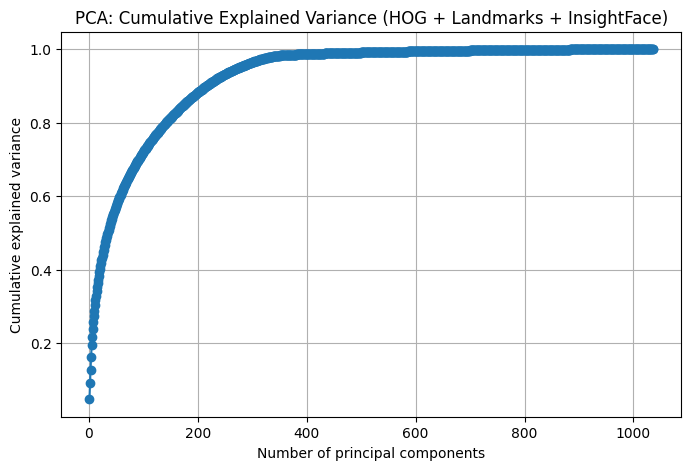

90% variance → 216 components
95% variance → 276 components
99% variance → 472 components


In [36]:
# Fit PCA on all components to inspect variance
pca_full = PCA(svd_solver="randomized", random_state=42)
pca_full.fit(X_scaled_hog_land)

expl_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.grid(True)
plt.title("PCA: Cumulative Explained Variance (HOG + Landmarks + InsightFace)")
plt.show()

# Optional: print how many components to reach 90%, 95%
for target in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cum_var, target) + 1
    print(f"{target*100:.0f}% variance → {k} components")

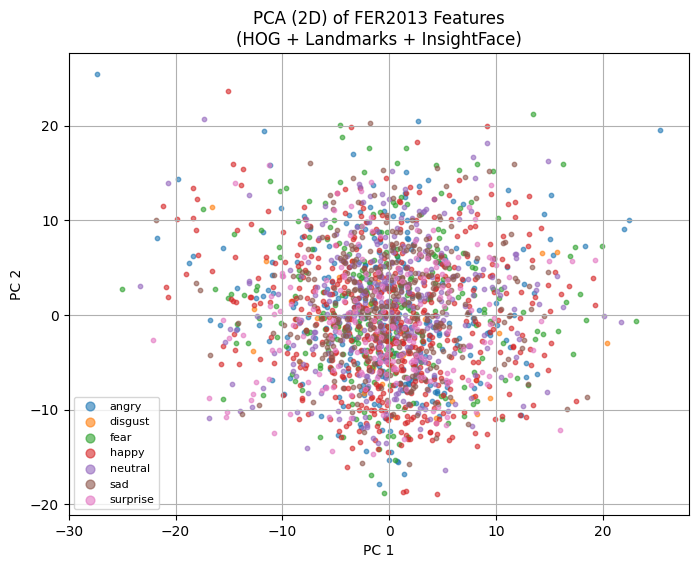

In [37]:
# 2D PCA for visualization
pca_vis = PCA(n_components=276, svd_solver="randomized", random_state=42)
X_vis_hog_land = pca_vis.fit_transform(X_scaled_hog_land)

# Subsample for plotting
n_plot = 2000
idx = np.random.choice(X_vis_hog_land.shape[0], size=n_plot, replace=False)
X_vis_sub = X_vis_hog_land[idx]
y_sub = y[idx]  # make sure y aligns with X_final

# If y are numeric 0–6, use emotion_names; if already strings, you can skip mapping
try:
    y_labels = np.array([emotion_names[int(c)] for c in y_sub])
except:
    y_labels = y_sub  # assume already strings

plt.figure(figsize=(8, 6))
for emo in np.unique(y_labels):
    mask = (y_labels == emo)
    plt.scatter(X_vis_sub[mask, 0],
                X_vis_sub[mask, 1],
                s=10,
                alpha=0.6,
                label=emo)

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA (2D) of FER2013 Features\n(HOG + Landmarks + InsightFace)")
plt.legend(markerscale=2, fontsize=8)
plt.grid(True)
plt.show()

In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X_vis_hog_land,
    y,
    test_size=0.20,      # 20% goes to val
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Temp (val) shape:", X_val.shape)

Train shape: (22967, 276)
Temp (val) shape: (5742, 276)


In [39]:
# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp,
#     y_temp,
#     test_size=0.50,     # split 30% into 15% / 15%
#     random_state=42,
#     stratify=y_temp
# )

print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Validation shape: (5742, 276)
Test shape: (7178, 596)


The `X_test` needs to be re-processed to match the dimensionality of the current `X_train` and `X_val` (276 components, from HOG + Landmarks features). This involves loading the test HOG and Landmark features, concatenating them, and then applying the `scaler` and `pca_vis` that were fitted on the HOG + Landmarks training data.

In [40]:
# Load raw HOG and Landmark features for the test set
X_test_hog = np.load("drive/MyDrive/datasci281/X_test_hog.npy")
X_test_land = np.load("drive/MyDrive/datasci281/X_test_land.npy")
X_test_arcface = np.load("drive/MyDrive/datasci281/X_test_arcface.npy")

# Concatenate HOG and Landmark features for the test set
X_test_hog_land_raw = np.hstack([X_test_hog, X_test_land])

print(f"Original X_test (HOG+Landmarks) shape: {X_test_hog_land_raw.shape}")

# Scale X_test_hog_land_raw using the *current* scaler (fitted on HOG+Landmarks training data)
X_test_scaled_hog_land = scaler.transform(X_test_hog_land_raw)

# Transform X_test_scaled_hog_land using the *current* pca_vis (fitted on HOG+Landmarks training data)
X_test_pca_hog_land = pca_vis.transform(X_test_scaled_hog_land)

print(f"Processed X_test (HOG+Landmarks) shape: {X_test_pca_hog_land.shape}")

# Update X_test to the new PCA-reduced version for consistency
X_test = X_test_pca_hog_land

print("\nNow all datasets have consistent feature dimensions:")
print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Original X_test (HOG+Landmarks) shape: (7178, 1036)
Processed X_test (HOG+Landmarks) shape: (7178, 276)

Now all datasets have consistent feature dimensions:
Train shape: (22967, 276)
Validation shape: (5742, 276)
Test shape: (7178, 276)


In [41]:
from sklearn.metrics import accuracy_score, precision_score, classification_report
best_lr = LogisticRegression(C=0.01, max_iter=3000, multi_class='multinomial', n_jobs=-1, solver='saga')
start_time = time()
best_lr.fit(X_train, y_train)
end_time = time()
print(f"HOG+Landmarks Logistic Regression Training Time: {end_time - start_time:.2f} seconds")

start_time = time()
y_val_pred_best_lr = best_lr.predict(X_val)
end_time = time()
print(f"HOG+Landmarks Logistic Regression Validation Prediction Time: {end_time - start_time:.2f} seconds")

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred_best_lr))
print(classification_report(y_val, y_val_pred_best_lr, target_names=emotion_names))

HOG+Landmarks Logistic Regression Training Time: 20.82 seconds
HOG+Landmarks Logistic Regression Validation Prediction Time: 0.00 seconds
Validation Accuracy: 0.5064437478230581
              precision    recall  f1-score   support

       angry       0.40      0.36      0.38       799
     disgust       0.46      0.14      0.21        87
        fear       0.32      0.21      0.26       820
       happy       0.66      0.79      0.72      1443
         sad       0.39      0.40      0.39       966
    surprise       0.56      0.57      0.57       634
     neutral       0.50      0.55      0.53       993

    accuracy                           0.51      5742
   macro avg       0.47      0.43      0.44      5742
weighted avg       0.49      0.51      0.49      5742



maybe the grid searh is needed

In [42]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     "C": [0.01, 0.1, 1, 5, 10],
#     "penalty": ["l2"],   # l1 requires special solvers
#     "solver": ["lbfgs", "saga"],
#     "class_weight": [None, "balanced"]
# }

# base_model = LogisticRegression(
#     max_iter=3000,
#     multi_class="multinomial",
#     n_jobs=-1
# )

# grid = GridSearchCV(
#     estimator=base_model,
#     param_grid=param_grid,
#     scoring="accuracy",   # you can also try "f1_macro"
#     cv=3,                 # 3-fold CV on TRAIN only
#     verbose=2,
#     n_jobs=-1
# )

# grid.fit(X_train, y_train)

In [43]:
# from sklearn.neural_network import MLPClassifier
# mlp = MLPClassifier(
#     hidden_layer_sizes=(128, 64, 32),  # ✅ 3 hidden layers
#     activation="relu",
#     solver="adam",
#     alpha=0.0005,        # L2 regularization
#     batch_size=64,
#     learning_rate="adaptive",
#     max_iter=200,
#     early_stopping=True,
#     random_state=42
# )

# mlp.fit(X_train, y_train)

In [44]:
# y_pred = mlp.predict(X_val)

# print("✅ Validation Accuracy:", accuracy_score(y_val, y_pred))
# print(classification_report(y_val, y_pred, target_names=emotion_names))

### Linear SVC Model

In [45]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### SVM pipeline

In [46]:
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(decision_function_shape="ovr"))
])


### Using RandomizedSearchCV for faster hyperparameter tuning

In [47]:
from sklearn.svm import LinearSVC
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(max_iter=5000))
])

rand_svm = RandomizedSearchCV(
    svm_pipeline,
    param_distributions={
        "svm__C": loguniform(1e-2, 1e1),
        "svm__class_weight": [None, "balanced"]
    },
    n_iter=6,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

start_time = time()
rand_svm.fit(X_train, y_train)
end_time = time()
print(f"LinearSVC RandomizedSearchCV Training Time: {end_time - start_time:.2f} seconds")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
LinearSVC RandomizedSearchCV Training Time: 11.38 seconds


### Validation performance

In [48]:
start_time = time()
y_val_pred = rand_svm.predict(X_val)
end_time = time()
print(f"LinearSVC Validation Prediction Time: {end_time - start_time:.2f} seconds")

val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average="weighted")

print("Validation Accuracy:", val_acc)
print("Validation Precision:", val_prec)
print(classification_report(y_val, y_val_pred))

LinearSVC Validation Prediction Time: 0.01 seconds
Validation Accuracy: 0.4965168930686172
Validation Precision: 0.46642945050895646
              precision    recall  f1-score   support

           0       0.42      0.32      0.37       799
           1       0.43      0.03      0.06        87
           2       0.32      0.13      0.18       820
           3       0.60      0.83      0.70      1443
           4       0.39      0.35      0.37       966
           5       0.52      0.60      0.56       634
           6       0.47      0.58      0.52       993

    accuracy                           0.50      5742
   macro avg       0.45      0.41      0.39      5742
weighted avg       0.47      0.50      0.47      5742



###Final test performance (FER-2013 results)

In [49]:
start_time = time()
y_test_pred = rand_svm.predict(X_test)
end_time = time()
print(f"LinearSVC Test Prediction Time: {end_time - start_time:.2f} seconds")

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average="weighted")

print("Test Accuracy:", test_acc)
print("Test Precision:", test_prec)
print(classification_report(y_test, y_test_pred))

LinearSVC Test Prediction Time: 0.02 seconds
Test Accuracy: 0.40401225968236276
Test Precision: 0.3834392283929954
              precision    recall  f1-score   support

           0       0.40      0.31      0.35       958
           1       0.67      0.04      0.07       111
           2       0.27      0.09      0.14      1024
           3       0.47      0.69      0.56      1774
           4       0.28      0.21      0.24      1247
           5       0.51      0.59      0.55       831
           6       0.33      0.42      0.37      1233

    accuracy                           0.40      7178
   macro avg       0.42      0.34      0.33      7178
weighted avg       0.38      0.40      0.38      7178



### SVM pipeline to run on PCA-reduced features, keeping the same train / val / test structure and metrics.

In [50]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, classification_report


### PCA with SVM Pipeline

In [51]:
pca_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(whiten=True, random_state=42)),
    ("svm", SVC(decision_function_shape="ovr"))
])


### RandomizedSearch on training data

In [52]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    "pca__n_components": [100, 150, 200],
    "svm__C": loguniform(1e-2, 1e2),
    "svm__class_weight": [None, "balanced"]
}

rand_pca_svm = RandomizedSearchCV(
    pca_svm_pipeline,
    param_distributions=param_dist,
    n_iter=10,          # ← huge speed-up
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

start_time = time()
rand_pca_svm.fit(X_train, y_train)
end_time = time()
print(f"PCA-SVM RandomizedSearchCV Training Time: {end_time - start_time:.2f} seconds")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
PCA-SVM RandomizedSearchCV Training Time: 668.21 seconds


### PCA with SVM Model

In [53]:
best_pca_svm = rand_pca_svm.best_estimator_

print("Best parameters:", rand_pca_svm.best_params_)


Best parameters: {'pca__n_components': 200, 'svm__C': np.float64(15.352246941973492), 'svm__class_weight': None}


### Validation performance

In [54]:
y_val_pred = best_pca_svm.predict(X_val)

start_time = time()
y_val_pred = best_pca_svm.predict(X_val)
end_time = time()
print(f"PCA-SVM Validation Prediction Time: {end_time - start_time:.2f} seconds")

val_acc = accuracy_score(y_val, y_val_pred)
val_prec = precision_score(y_val, y_val_pred, average="weighted")

print("Validation Accuracy:", val_acc)
print("Validation Precision:", val_prec)
print(classification_report(y_val, y_val_pred))

PCA-SVM Validation Prediction Time: 36.49 seconds
Validation Accuracy: 0.5350052246603971
Validation Precision: 0.5311842229225943
              precision    recall  f1-score   support

           0       0.43      0.43      0.43       799
           1       0.89      0.29      0.43        87
           2       0.44      0.34      0.39       820
           3       0.64      0.77      0.70      1443
           4       0.42      0.42      0.42       966
           5       0.66      0.62      0.64       634
           6       0.52      0.52      0.52       993

    accuracy                           0.54      5742
   macro avg       0.57      0.48      0.50      5742
weighted avg       0.53      0.54      0.53      5742



### Final test evaluation

PCA-SVM Test Prediction Time: 40.49 seconds
Test Accuracy: 0.43995541933686266
Test Precision: 0.44530833151871596
              precision    recall  f1-score   support

           0       0.45      0.44      0.44       958
           1       0.94      0.30      0.45       111
           2       0.37      0.24      0.29      1024
           3       0.53      0.57      0.55      1774
           4       0.30      0.35      0.32      1247
           5       0.64      0.63      0.63       831
           6       0.36      0.40      0.37      1233

    accuracy                           0.44      7178
   macro avg       0.51      0.42      0.44      7178
weighted avg       0.45      0.44      0.44      7178


--- Confusion Matrix (PCA-SVM Test Set) ---


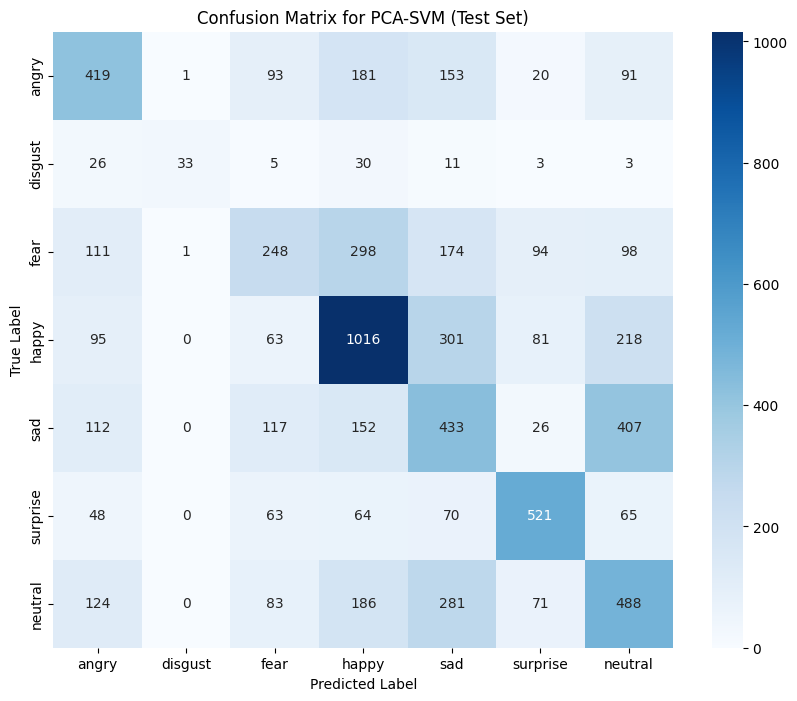

In [55]:
start_time = time()
y_test_pred = best_pca_svm.predict(X_test)
end_time = time()
print(f"PCA-SVM Test Prediction Time: {end_time - start_time:.2f} seconds")

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, average="weighted")

print("Test Accuracy:", test_acc)
print("Test Precision:", test_prec)
print(classification_report(y_test, y_test_pred))

# Confusion Matrix for PCA-SVM (Test Set)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Confusion Matrix (PCA-SVM Test Set) ---")
# Compute confusion matrix
cm_pca_svm = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_pca_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for PCA-SVM (Test Set)')
plt.show()

### Inspect PCA compression

In [56]:
best_pca = best_pca_svm.named_steps["pca"]

print("Number of components:", best_pca.n_components_)
print("Explained variance ratio:", best_pca.explained_variance_ratio_.sum())


Number of components: 200
Explained variance ratio: 0.7423356


### Nonlinear PCA-SVM for HOG + Landmarks Features

To apply a nonlinear SVM effectively, and ensure correct preprocessing within the pipeline, we need to start with the `X_hog_land` dataset (the combined HOG and Landmark features *before* any PCA) and re-split it for training and validation. The test data will also be prepared from its raw HOG+Landmark components.

In [57]:
# Re-split the combined features (HOG+Landmarks+ArcFace) for the nonlinear SVM
X_train_nl, X_val_nl, y_train_nl, y_val_nl = train_test_split(
    X_final, # Use the raw combined features (HOG+Landmarks+ArcFace)
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Prepare X_test_nl similarly from raw HOG+Landmarks+ArcFace
X_test_full_raw_nl = np.load("drive/MyDrive/datasci281/X_test_embeddings.npy") # Load the raw combined test features
y_test_nl = np.load("drive/MyDrive/datasci281/y_test_embeddings.npy") # Load y_test_nl here

print("Train shape (for nonlinear SVM):", X_train_nl.shape)
print("Validation shape (for nonlinear SVM):", X_val_nl.shape)
print("Test shape (for nonlinear SVM):", X_test_full_raw_nl.shape)

# Update the variable name for test set to match previous usage in evaluation cells
X_test_nl = X_test_full_raw_nl

Train shape (for nonlinear SVM): (22967, 1548)
Validation shape (for nonlinear SVM): (5742, 1548)
Test shape (for nonlinear SVM): (7178, 1548)


### Define and Tune Nonlinear PCA-SVM Pipeline 

We'll define a pipeline that scales the features, then applies PCA, and finally trains a `SVC` with a nonlinear kernel. `RandomizedSearchCV` will be used to efficiently search for the best combination of hyperparameters.

In [58]:
# Define nonlinear PCA-SVM pipeline
nonlinear_pca_svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)), # PCA components will be tuned
    ("svm", SVC(decision_function_shape="ovr", random_state=42)) # SVC for nonlinear kernels
])

# Define parameter distributions for RandomizedSearchCV
# Increased the search space for PCA components to reflect the full feature set
param_dist_nonlinear = {
    "pca__n_components": [100, 150, 200, 276, 300, 400, 500, 596], # Explore various components based on X_final
    "svm__C": loguniform(1e-2, 1e2),
    "svm__kernel": ['rbf', 'poly'],
    "svm__gamma": loguniform(1e-3, 1e0), # Relevant for 'rbf', 'poly', 'sigmoid'
    "svm__degree": [2, 3], # Only relevant for 'poly' kernel
    "svm__class_weight": [None, "balanced"]
}

rand_nonlinear_pca_svm = RandomizedSearchCV(
    nonlinear_pca_svm_pipeline,
    param_distributions=param_dist_nonlinear,
    n_iter=15,          # Number of parameter settings that are sampled
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

start_time = time()
rand_nonlinear_pca_svm.fit(X_train_nl, y_train_nl)
end_time = time()
print(f"Nonlinear PCA-SVM RandomizedSearchCV Training Time: {end_time - start_time:.2f} seconds")

print("Best parameters:", rand_nonlinear_pca_svm.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Nonlinear PCA-SVM RandomizedSearchCV Training Time: 1575.82 seconds
Best parameters: {'pca__n_components': 276, 'svm__C': np.float64(2.796485951606246), 'svm__class_weight': None, 'svm__degree': 3, 'svm__gamma': np.float64(0.0011727009450102248), 'svm__kernel': 'rbf'}


### Evaluate Nonlinear PCA-SVM Performance with HOG+LAND+ARCFACE combined feature set

Now we'll evaluate the best model found by `RandomizedSearchCV` on both the validation and test datasets.


--- Validation Performance (Nonlinear PCA-SVM) ---
Nonlinear PCA-SVM Validation Prediction Time: 45.88 seconds
Validation Accuracy: 0.6859979101358412
Validation Precision: 0.6882494011723632
              precision    recall  f1-score   support

       angry       0.59      0.62      0.60       799
     disgust       1.00      0.48      0.65        87
        fear       0.62      0.54      0.58       820
       happy       0.80      0.86      0.83      1443
         sad       0.60      0.64      0.62       966
    surprise       0.82      0.74      0.78       634
     neutral       0.64      0.65      0.64       993

    accuracy                           0.69      5742
   macro avg       0.72      0.65      0.67      5742
weighted avg       0.69      0.69      0.68      5742


--- Test Performance (Nonlinear PCA-SVM) ---
Nonlinear PCA-SVM Test Prediction Time: 57.93 seconds
Test Accuracy: 0.5530788520479242
Test Precision: 0.5655304490639156
              precision    recall  f1-sco

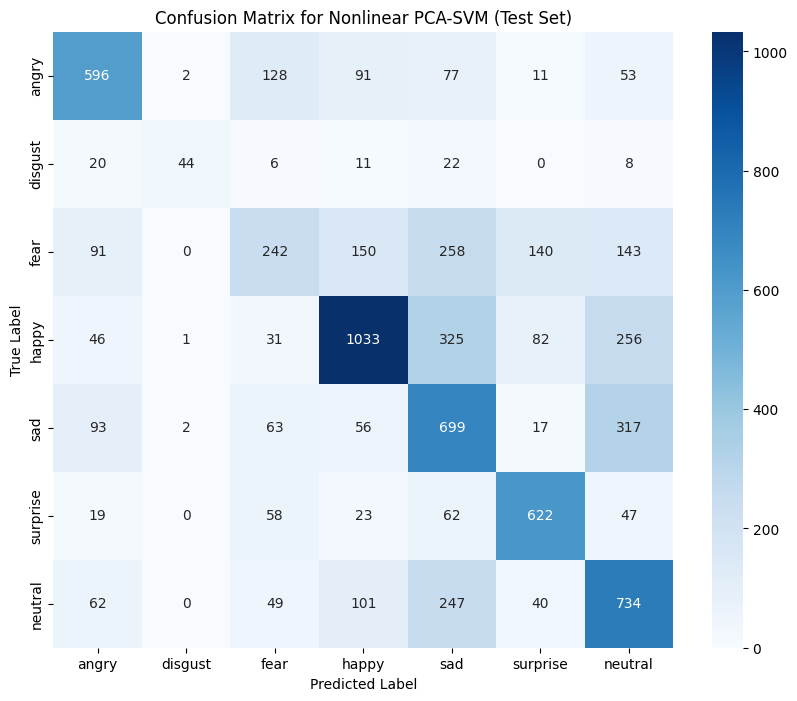

In [59]:
best_nonlinear_pca_svm = rand_nonlinear_pca_svm.best_estimator_

# Validation performance
print("\n--- Validation Performance (Nonlinear PCA-SVM) ---")
start_time = time()
y_val_pred_nl = best_nonlinear_pca_svm.predict(X_val_nl)
end_time = time()
print(f"Nonlinear PCA-SVM Validation Prediction Time: {end_time - start_time:.2f} seconds")

val_acc_nl = accuracy_score(y_val_nl, y_val_pred_nl)
val_prec_nl = precision_score(y_val_nl, y_val_pred_nl, average="weighted")

print("Validation Accuracy:", val_acc_nl)
print("Validation Precision:", val_prec_nl)
print(classification_report(y_val_nl, y_val_pred_nl, target_names=emotion_names))

# Test performance
print("\n--- Test Performance (Nonlinear PCA-SVM) ---")
start_time = time()
y_test_pred_nl = best_nonlinear_pca_svm.predict(X_test_nl)
end_time = time()
print(f"Nonlinear PCA-SVM Test Prediction Time: {end_time - start_time:.2f} seconds")

test_acc_nl = accuracy_score(y_test_nl, y_test_pred_nl)
test_prec_nl = precision_score(y_test_nl, y_test_pred_nl, average="weighted")

print("Test Accuracy:", test_acc_nl)
print("Test Precision:", test_prec_nl)
print(classification_report(y_test_nl, y_test_pred_nl, target_names=emotion_names))

# Confusion Matrix for Nonlinear PCA-SVM (Test Set)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Confusion Matrix (Test Set) ---")
# Compute confusion matrix
cm = confusion_matrix(y_test_nl, y_test_pred_nl)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Nonlinear PCA-SVM (Test Set)')
plt.show()


--- Training Performance (Nonlinear PCA-SVM) ---
Nonlinear PCA-SVM Training Prediction Time: 174.56 seconds
Training Accuracy: 0.9983454521705055
Training Precision: 0.998344993634757
              precision    recall  f1-score   support

       angry       1.00      1.00      1.00      3196
     disgust       1.00      0.99      1.00       349
        fear       1.00      1.00      1.00      3277
       happy       1.00      1.00      1.00      5772
         sad       1.00      1.00      1.00      3864
    surprise       1.00      1.00      1.00      2537
     neutral       1.00      1.00      1.00      3972

    accuracy                           1.00     22967
   macro avg       1.00      1.00      1.00     22967
weighted avg       1.00      1.00      1.00     22967


--- Validation Performance (Nonlinear PCA-SVM) ---
Nonlinear PCA-SVM Validation Prediction Time: 43.12 seconds
Validation Accuracy: 0.6859979101358412
Validation Precision: 0.6882494011723632
              precision  

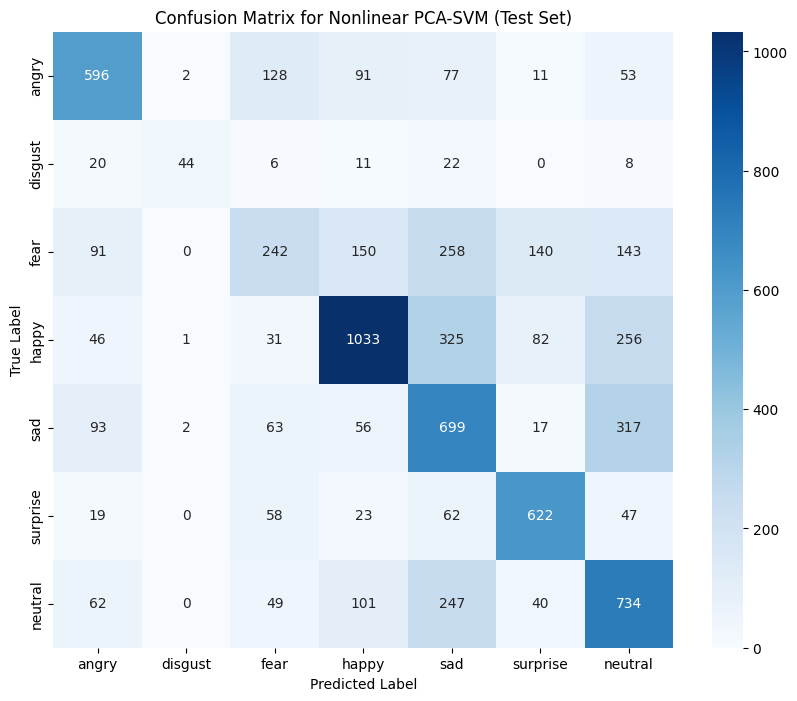

In [60]:
best_nonlinear_pca_svm = rand_nonlinear_pca_svm.best_estimator_

# Training performance
print("\n--- Training Performance (Nonlinear PCA-SVM) ---")
start_time = time()
y_train_pred_nl = best_nonlinear_pca_svm.predict(X_train_nl)
end_time = time()
print(f"Nonlinear PCA-SVM Training Prediction Time: {end_time - start_time:.2f} seconds")

train_acc_nl = accuracy_score(y_train_nl, y_train_pred_nl)
train_prec_nl = precision_score(y_train_nl, y_train_pred_nl, average="weighted")

print("Training Accuracy:", train_acc_nl)
print("Training Precision:", train_prec_nl)
print(classification_report(y_train_nl, y_train_pred_nl, target_names=emotion_names))

# Validation performance
print("\n--- Validation Performance (Nonlinear PCA-SVM) ---")
start_time = time()
y_val_pred_nl = best_nonlinear_pca_svm.predict(X_val_nl)
end_time = time()
print(f"Nonlinear PCA-SVM Validation Prediction Time: {end_time - start_time:.2f} seconds")

val_acc_nl = accuracy_score(y_val_nl, y_val_pred_nl)
val_prec_nl = precision_score(y_val_nl, y_val_pred_nl, average="weighted")

print("Validation Accuracy:", val_acc_nl)
print("Validation Precision:", val_prec_nl)
print(classification_report(y_val_nl, y_val_pred_nl, target_names=emotion_names))

# Test performance
print("\n--- Test Performance (Nonlinear PCA-SVM) ---")
start_time = time()
y_test_pred_nl = best_nonlinear_pca_svm.predict(X_test_nl)
end_time = time()
print(f"Nonlinear PCA-SVM Test Prediction Time: {end_time - start_time:.2f} seconds")

test_acc_nl = accuracy_score(y_test_nl, y_test_pred_nl)
test_prec_nl = precision_score(y_test_nl, y_test_pred_nl, average="weighted")

print("Test Accuracy:", test_acc_nl)
print("Test Precision:", test_prec_nl)
print(classification_report(y_test_nl, y_test_pred_nl, target_names=emotion_names))

# Confusion Matrix for Nonlinear PCA-SVM (Test Set)
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\n--- Confusion Matrix (Test Set) ---")
# Compute confusion matrix
cm = confusion_matrix(y_test_nl, y_test_pred_nl)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_names, yticklabels=emotion_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Nonlinear PCA-SVM (Test Set)')
plt.show()

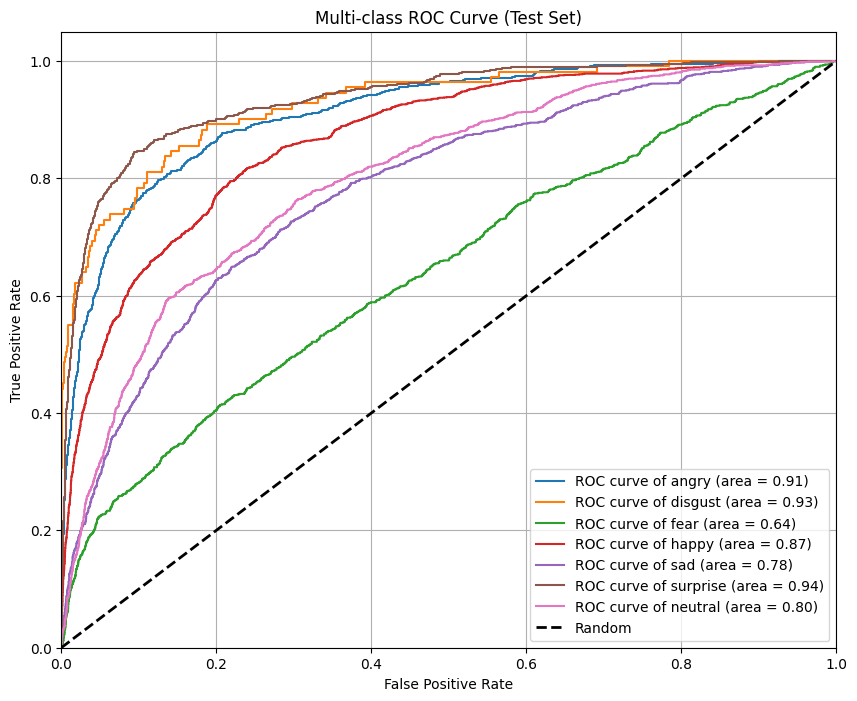

In [61]:
# Multi-class ROC Curve for Test Performance

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize the true labels for multi-class ROC
n_classes = len(emotion_names)
y_test_binarized = label_binarize(y_test_nl, classes=np.arange(n_classes))

# Get decision function scores (or probabilities if available and probability=True was set)
# Since SVC was not trained with probability=True, we use decision_function
y_score = best_nonlinear_pca_svm.decision_function(X_test_nl)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of {emotion_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()